<a href="https://colab.research.google.com/github/NargesJeddi/TopoGAT/blob/main/TopoGAT_synthetic_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ripser
!pip install persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=cdbeaf23fc35e4c01c378408fd38de8bf23f070b6f8f8a8213bbaf62cdb74ad3
  Stored in directory: /root/.cache/pip/wheels/1f/cc/2d/de23a8b9ae586817b0b44de4a4b1a08f23473e248a644b312f
Successfully built hopcroftkarp


In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GATConv
from ripser import ripser
from persim import PersistenceImager
from sklearn.metrics import roc_auc_score, f1_score
import random

# -------------------------------
# 1. Generate Synthetic Graph with Anomaly
# -------------------------------
def generate_synthetic_graph(n=100, p=0.05, anomaly_size=5):
    G = nx.erdos_renyi_graph(n, p)
    anomaly_nodes = list(range(n, n + anomaly_size))
    G.add_nodes_from(anomaly_nodes)
    for i in anomaly_nodes:
        for j in anomaly_nodes:
            if i != j:
                G.add_edge(i, j)
    for node in G.nodes():
        G.nodes[node]['x'] = torch.randn(10)  # 10-dim random features
    return G, anomaly_nodes

G, anomaly_nodes = generate_synthetic_graph()
positions = nx.spring_layout(G)
degree = np.array([val for _, val in G.degree()])
thresholds = [0, 2, 4, 6]

# Convert to PyG format
data = from_networkx(G)
data.x = torch.stack([G.nodes[n]['x'] for n in G.nodes()])

# -------------------------------
# 2. Compute Topological Features via GFL
# -------------------------------
pimgr = PersistenceImager(pixel_size=0.1)
pimgr.fit([np.array([[0, 1]])])  # dummy fit

topo_feature_list = []
for node in range(data.num_nodes):
    features = []
    for t in thresholds:
        neighbors = [n for n in G.neighbors(node) if degree[n] >= t]
        subG = G.subgraph(neighbors + [node])
        if subG.number_of_edges() == 0:
            continue
        coords = np.array([positions[n] for n in subG.nodes])
        D = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
        dgms = ripser(D, distance_matrix=True)['dgms']
        dgm1 = dgms[1] if len(dgms) > 1 else np.zeros((0, 2))
        img = pimgr.transform(dgm1)
        features.append(torch.tensor(img.flatten(), dtype=torch.float32))
    if features:
        topo_feature_list.append(torch.stack(features).mean(dim=0))
    else:
        topo_feature_list.append(torch.zeros_like(torch.tensor(img.flatten(), dtype=torch.float32)))

node_topo_feats = torch.stack(topo_feature_list)
node_topo_feats = torch.nan_to_num(node_topo_feats)
topo_feat_dim = node_topo_feats.shape[1]

# -------------------------------
# 3. Topology-Aware GAT Definition
# -------------------------------
class TopoAwareGAT(nn.Module):
    def __init__(self, in_dim, topo_dim, hidden_dim, out_dim, heads=8):
        super().__init__()
        self.mlp_topo = nn.Sequential(
            nn.Linear(topo_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.gat1 = GATConv(in_dim + 32, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index, topo_feats):
        z_topo = self.mlp_topo(topo_feats)
        x_aug = torch.cat([x, z_topo], dim=1)
        x = F.elu(self.gat1(x_aug, edge_index))
        x = self.gat2(x, edge_index)
        return x

# -------------------------------
# 4. Inject Anomalies + Prepare Data
# -------------------------------
labels = torch.zeros(data.num_nodes)
labels[anomaly_nodes] = 1
data.x[anomaly_nodes] = torch.randn_like(data.x[anomaly_nodes])

# Random train/test masks
indices = list(range(data.num_nodes))
random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx = indices[:split]
test_idx = indices[split:]
train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# -------------------------------
# 5. Train Topology-Aware GAT
# -------------------------------
model = TopoAwareGAT(in_dim=data.x.shape[1], topo_dim=topo_feat_dim, hidden_dim=8, out_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, node_topo_feats)
    loss = criterion(out[train_mask], labels[train_mask].long())
    loss.backward()
    optimizer.step()

# -------------------------------
# 6. Evaluate
# -------------------------------
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index, node_topo_feats)
    probs = F.softmax(logits[test_mask], dim=1)[:, 1]
    preds = (probs > 0.5).float()
    y_true = labels[test_mask]
    auc = roc_auc_score(y_true.cpu(), probs.cpu())
    f1 = f1_score(y_true.cpu(), preds.cpu())
    print(f"Test AUC: {auc:.4f}, F1 Score: {f1:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Test AUC: 1.0000, F1 Score: 1.0000


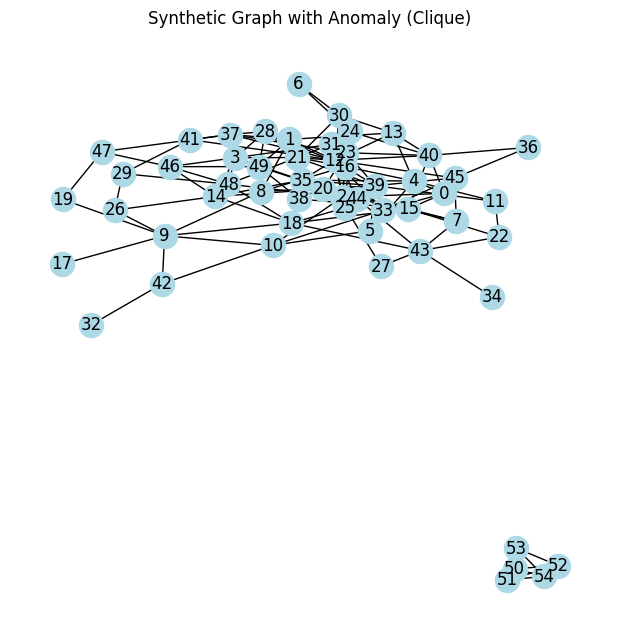

<ipython-input-3-72cbf184fec2>:58: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(img, cmap='hot', interpolation='nearest')
<ipython-input-3-72cbf184fec2>:58: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(img, cmap='hot', interpolation='nearest')


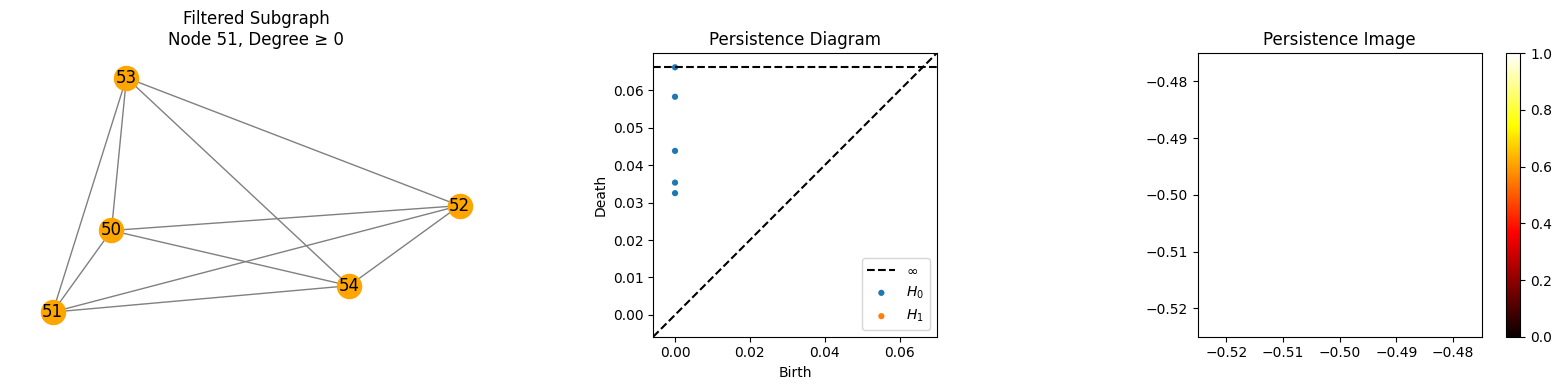

<ipython-input-3-72cbf184fec2>:58: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(img, cmap='hot', interpolation='nearest')
<ipython-input-3-72cbf184fec2>:58: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(img, cmap='hot', interpolation='nearest')


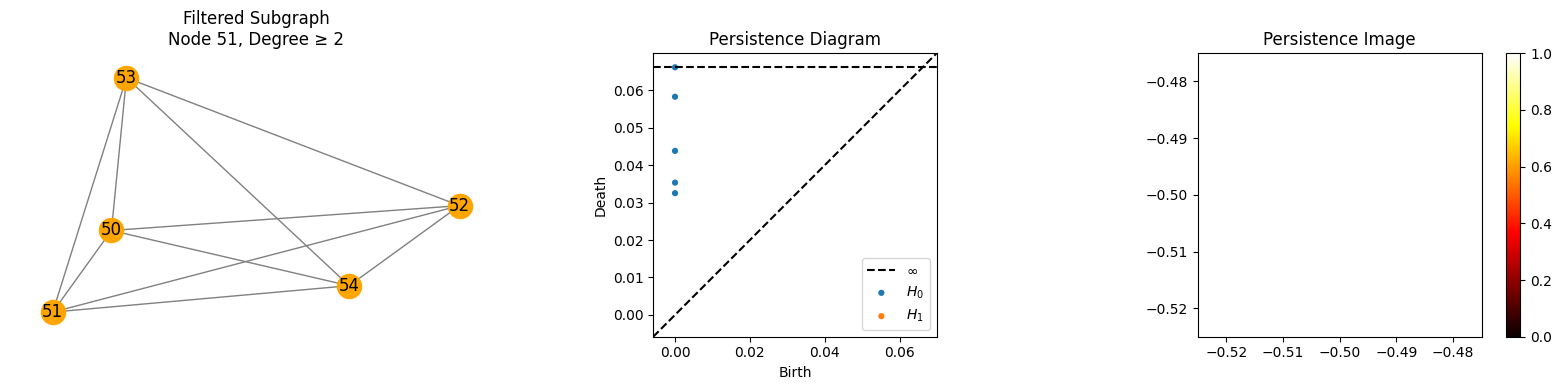

<ipython-input-3-72cbf184fec2>:58: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(img, cmap='hot', interpolation='nearest')
<ipython-input-3-72cbf184fec2>:58: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(img, cmap='hot', interpolation='nearest')


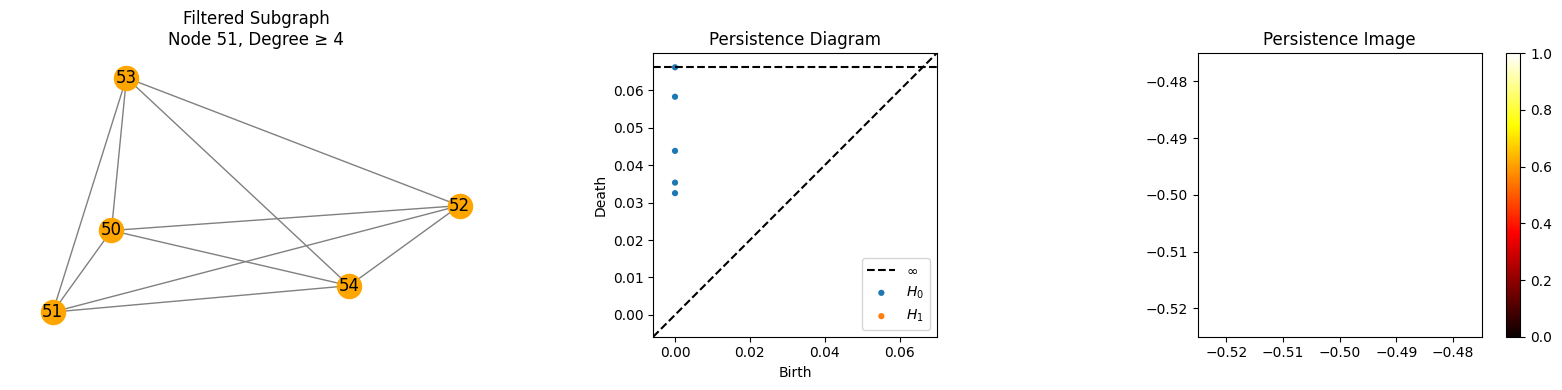

In [ ]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from ripser import ripser
from persim import plot_diagrams, PersistenceImager

# Create a synthetic graph with embedded anomaly (clique)
def generate_synthetic_graph(n=50, p=0.1, anomaly_size=5):
    G = nx.erdos_renyi_graph(n, p)
    anomaly_nodes = list(range(n, n + anomaly_size))
    G.add_nodes_from(anomaly_nodes)
    for i in anomaly_nodes:
        for j in anomaly_nodes:
            if i != j:
                G.add_edge(i, j)
    return G

# Generate graph and setup
G = generate_synthetic_graph()
positions = nx.spring_layout(G)
degree = np.array([val for _, val in G.degree()])
thresholds = [0, 2, 4, 6]

# Plot original synthetic graph
plt.figure(figsize=(6, 6))
nx.draw(G, pos=positions, with_labels=True, node_color='lightblue')
plt.title("Synthetic Graph with Anomaly (Clique)")
plt.show()

# Function to plot filtration + persistence for a node
def plot_filtration_pipeline_synthetic(node_id, G, positions, thresholds, degree):
    pimgr = PersistenceImager(pixel_size=0.1)
    pimgr.fit([np.array([[0, 1]])])  # Dummy fit

    for t in thresholds:
        neighbors = [n for n in G.neighbors(node_id) if degree[n] >= t]
        subG = G.subgraph(neighbors + [node_id])
        if subG.number_of_edges() == 0:
            continue

        coords = np.array([positions[n] for n in subG.nodes])
        D = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
        dgms = ripser(D, distance_matrix=True)['dgms']
        dgm1 = dgms[1] if len(dgms) > 1 else np.zeros((0, 2))
        img = pimgr.transform(dgm1)

        # Plot filtered subgraph, persistence diagram, and image
        plt.figure(figsize=(16, 4))
        plt.subplot(1, 3, 1)
        nx.draw(subG, pos=positions, with_labels=True, node_color='orange', edge_color='gray')
        plt.title(f"Filtered Subgraph\nNode {node_id}, Degree ≥ {t}")

        plt.subplot(1, 3, 2)
        plot_diagrams(dgms, ax=plt.gca(), title="Persistence Diagram")

        plt.subplot(1, 3, 3)
        plt.imshow(img, cmap='hot', interpolation='nearest')
        plt.title("Persistence Image")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

# Plot for a node from the anomaly clique
plot_filtration_pipeline_synthetic(node_id=51, G=G, positions=positions, thresholds=thresholds, degree=degree)


In [ ]:
#GCN for synthetic data
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score, f1_score
import random
import networkx as nx

# 1. Create synthetic graph
num_nodes = 100
G_nx = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G_nx.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# 2. Generate node features
x = torch.randn((num_nodes, 16))

# 3. Inject feature anomalies
anomaly_ratio = 0.1
num_anomalies = int(anomaly_ratio * num_nodes)
anomaly_indices = random.sample(range(num_nodes), num_anomalies)
labels = torch.zeros(num_nodes)
labels[anomaly_indices] = 1
x[anomaly_indices] = torch.randn_like(x[anomaly_indices]) * 3

# 4. Train/test mask
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask

# 5. Package as PyG data
data = Data(x=x, edge_index=edge_index, y=labels, train_mask=train_mask, test_mask=test_mask)

# 6. GCN model
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

model = GCN(in_dim=16, hidden_dim=8, out_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 7. Training loop
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask].long())
    loss.backward()
    optimizer.step()

# 8. Evaluation
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits[test_mask], dim=1)[:, 1]
    preds = (probs > 0.5).float()
    y_true = data.y[test_mask]
    auc = roc_auc_score(y_true.cpu(), probs.cpu())
    f1 = f1_score(y_true.cpu(), preds.cpu())
    print(f"Test AUC: {auc:.4f}, F1 Score: {f1:.4f}")


Test AUC: 0.5586, F1 Score: 0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.metrics import roc_auc_score, f1_score
import random
import networkx as nx

# 1. Create synthetic graph
num_nodes = 100
G_nx = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G_nx.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# 2. Generate node features
x = torch.randn((num_nodes, 16))

# 3. Inject feature anomalies
anomaly_ratio = 0.1
num_anomalies = int(anomaly_ratio * num_nodes)
anomaly_indices = random.sample(range(num_nodes), num_anomalies)
labels = torch.zeros(num_nodes)
labels[anomaly_indices] = 1
x[anomaly_indices] = torch.randn_like(x[anomaly_indices]) * 3

# 4. Train/test mask
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask

# 5. Package data
data = Data(x=x, edge_index=edge_index, y=labels, train_mask=train_mask, test_mask=test_mask)

# 6. Define GAT model
class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        return self.gat2(x, edge_index)

# 7. Model setup
model = GAT(in_dim=16, hidden_dim=8, out_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 8. Training loop
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask].long())
    loss.backward()
    optimizer.step()

# 9. Evaluation
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits[test_mask], dim=1)[:, 1]
    preds = (probs > 0.5).float()
    y_true = data.y[test_mask]
    auc = roc_auc_score(y_true.cpu(), probs.cpu())
    f1 = f1_score(y_true.cpu(), preds.cpu())
    print(f"Test AUC: {auc:.4f}, F1 Score: {f1:.4f}")


Test AUC: 0.6275, F1 Score: 0.2500


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import average_precision_score
import random
import networkx as nx
import copy

# Create synthetic graph
num_nodes = 500
G_nx = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G_nx.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Generate identical features
x = torch.randn((num_nodes, 16))

# Inject same anomalies
anomaly_ratio = 0.1
num_anomalies = int(anomaly_ratio * num_nodes)
anomaly_indices = random.sample(range(num_nodes), num_anomalies)
labels = torch.zeros(num_nodes)
labels[anomaly_indices] = 1
x_anom = x.clone()
x_anom[anomaly_indices] = torch.randn_like(x_anom[anomaly_indices]) * 3

# Masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask

# Base data for both models
base_data = Data(x=x_anom, edge_index=edge_index, y=labels,
                 train_mask=train_mask, test_mask=test_mask)

# GCN model
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# GAT model
class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        return self.gat2(x, edge_index)

def train_and_eval(model, data):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask].long())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits[data.test_mask], dim=1)[:, 1]
        preds = (probs > 0.5).float()
        y_true = data.y[data.test_mask]
        auc = roc_auc_score(y_true.cpu(), probs.cpu())
        f1 = f1_score(y_true.cpu(), preds.cpu())
        auc_pr = average_precision_score(y_true.cpu(), probs.cpu())
    return auc, f1, auc_pr
# Run GCN
gcn_data = copy.deepcopy(base_data)
gcn_model = GCN(in_dim=16, hidden_dim=8, out_dim=2)
gcn_auc, gcn_f1, gcn_aucpr = train_and_eval(gcn_model, gcn_data)


# Run GAT
gat_data = copy.deepcopy(base_data)
gat_model = GAT(in_dim=16, hidden_dim=8, out_dim=2, heads=4)
gat_auc, gat_f1, gat_aucpr = train_and_eval(gat_model, gat_data)

# Show comparison
print("=== Anomaly Detection Performance ===")
print(f"GCN - AUC: {gcn_auc:.4f}, F1: {gcn_f1:.4f}, AUC-PR: {gcn_aucpr:.4f}")
print(f"GAT - AUC: {gat_auc:.4f}, F1: {gat_f1:.4f}, AUC-PR: {gat_aucpr:.4f}")



=== Anomaly Detection Performance ===
GCN - AUC: 0.5111, F1: 0.0000, AUC-PR: 0.0989
GAT - AUC: 0.5590, F1: 0.2083, AUC-PR: 0.1822


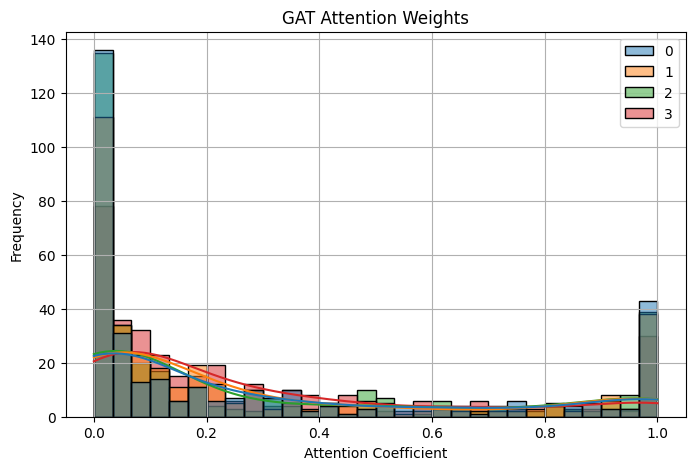

In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random

# Synthetic graph
num_nodes = 100
G_nx = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G_nx.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
x = torch.randn((num_nodes, 16))

# Anomalies
anomaly_indices = random.sample(range(num_nodes), int(0.1 * num_nodes))
labels = torch.zeros(num_nodes)
labels[anomaly_indices] = 1
x[anomaly_indices] = torch.randn_like(x[anomaly_indices]) * 3

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask
data = Data(x=x, edge_index=edge_index, y=labels, train_mask=train_mask, test_mask=test_mask)

# GAT model
class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index, return_attention=False):
        if return_attention:
            x, attn_weights = self.gat1(x, edge_index, return_attention_weights=True)
            x = F.elu(x)
            x = self.gat2(x, edge_index)
            return x, attn_weights
        else:
            x = F.elu(self.gat1(x, edge_index))
            return self.gat2(x, edge_index)

# Train GAT
model = GAT(16, 8, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
for _ in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], labels[train_mask].long())
    loss.backward()
    optimizer.step()

# Extract attention weights
model.eval()
with torch.no_grad():
    _, attn_weights = model(data.x, data.edge_index, return_attention=True)
alpha = attn_weights[1].squeeze().cpu().numpy()

# Plot attention weights
plt.figure(figsize=(8, 5))
sns.histplot(alpha, bins=30, kde=True)
plt.title("GAT Attention Weights")
plt.xlabel("Attention Coefficient")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torch_geometric.utils import to_networkx
from ripser import ripser
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import random

# Generate synthetic graph
num_nodes = 100
G_nx = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G_nx.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

# Generate node features and anomalies
x = torch.randn((num_nodes, 16))
anomaly_ratio = 0.1
num_anomalies = int(anomaly_ratio * num_nodes)
anomaly_indices = random.sample(range(num_nodes), num_anomalies)
labels = torch.zeros(num_nodes)
labels[anomaly_indices] = 1
x[anomaly_indices] = torch.randn_like(x[anomaly_indices]) * 3

# Topological features using persistence diagram lifespans
positions = nx.spring_layout(G_nx)
topo_features = []
for node in range(num_nodes):
    neighbors = list(G_nx.neighbors(node)) + [node]
    subG = G_nx.subgraph(neighbors)
    coords = np.array([positions[n] for n in subG.nodes])
    if len(coords) < 2:
        topo_features.append([0])
        continue
    D = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
    dgms = ripser(D, distance_matrix=True)['dgms']
    dgm1 = dgms[1] if len(dgms) > 1 else np.zeros((0, 2))
    lifespans = dgm1[:, 1] - dgm1[:, 0] if len(dgm1) > 0 else np.array([0.])
    topo_features.append([np.mean(lifespans)])

topo_features = np.array(topo_features)
scaler = MinMaxScaler()
topo_features = scaler.fit_transform(topo_features)
topo_tensor = torch.tensor(topo_features, dtype=torch.float32)

# Train/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask

# Build PyG Data object
data = Data(x=x, edge_index=edge_index, y=labels, train_mask=train_mask, test_mask=test_mask)

# GAT with topological feature
class TopoGAT(nn.Module):
    def __init__(self, in_dim, topo_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.mlp_topo = nn.Sequential(
            nn.Linear(topo_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.gat1 = GATConv(in_dim + 8, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index, topo_feats):
        z_topo = self.mlp_topo(topo_feats)
        x_aug = torch.cat([x, z_topo], dim=1)
        x = F.elu(self.gat1(x_aug, edge_index))
        return self.gat2(x, edge_index)

# Train model
model = TopoGAT(in_dim=16, topo_dim=1, hidden_dim=8, out_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, topo_tensor)
    loss = criterion(out[data.train_mask], data.y[data.train_mask].long())
    loss.backward()
    optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index, topo_tensor)
    probs = F.softmax(logits[data.test_mask], dim=1)[:, 1]
    preds = (probs > 0.5).float()
    y_true = data.y[data.test_mask]
    auc = roc_auc_score(y_true.cpu(), probs.cpu())
    f1 = f1_score(y_true.cpu(), preds.cpu())
    result = f"TopoGAT - AUC: {auc:.4f}, F1: {f1:.4f}"
result


'TopoGAT - AUC: 0.6400, F1: 0.2222'

In [ ]:
# Install required packages
#!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
#!pip install networkx scikit-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import average_precision_score
import random

# Step 1: Create synthetic graph
num_nodes = 200
G = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Inject node features and anomalies
x = torch.randn((num_nodes, 16))
labels = torch.zeros(num_nodes)
anomaly_indices = random.sample(range(num_nodes), int(0.1 * num_nodes))
labels[anomaly_indices] = 1
x[anomaly_indices] = torch.randn_like(x[anomaly_indices]) * 3

# Step 2: Graph-based filtrations
degree = np.array([val for _, val in G.degree()])
closeness = np.array(list(nx.closeness_centrality(G).values()))
betweenness = np.array(list(nx.betweenness_centrality(G).values()))
filtrations = np.vstack([degree, closeness, betweenness]).T
topo_feats = torch.tensor(MinMaxScaler().fit_transform(filtrations), dtype=torch.float32)

# Step 3: GAT + MLP
class TopoGAT(nn.Module):
    def __init__(self, in_dim, topo_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(topo_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.gat1 = GATConv(in_dim + 8, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index, topo):
        topo_embed = self.mlp(topo)
        x_comb = torch.cat([x, topo_embed], dim=1)
        h = F.elu(self.gat1(x_comb, edge_index))
        return self.gat2(h, edge_index)

# Setup and train
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask

data = Data(x=x, edge_index=edge_index, y=labels, train_mask=train_mask, test_mask=test_mask)

model = TopoGAT(16, 3, 8, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, topo_feats)
    loss = criterion(out[data.train_mask], data.y[data.train_mask].long())
    loss.backward()
    optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index, topo_feats)
    probs = F.softmax(logits[data.test_mask], dim=1)[:, 1]
    preds = (probs > 0.5).float()
    y_true = data.y[data.test_mask]
    auc = roc_auc_score(y_true.cpu(), probs.cpu())
    f1 = f1_score(y_true.cpu(), preds.cpu())
    auc_pr = average_precision_score(y_true.cpu(), probs.cpu())
    print(f"AUC: {auc:.4f}, F1: {f1:.4f}, AUC-PR: {auc_pr:.4f}")


AUC: 0.4325, F1: 0.0000, AUC-PR: 0.0878


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Plot the synthetic graph with anomalies in red
def plot_graph(G, anomaly_indices):
    pos = nx.spring_layout(G, seed=42)
    colors = ['red' if i in anomaly_indices else 'lightblue' for i in G.nodes()]
    nx.draw(G, pos, node_color=colors, with_labels=False, node_size=80, edge_color='gray')
    plt.title("Synthetic Graph with Anomalies")
    plt.show()

GFL


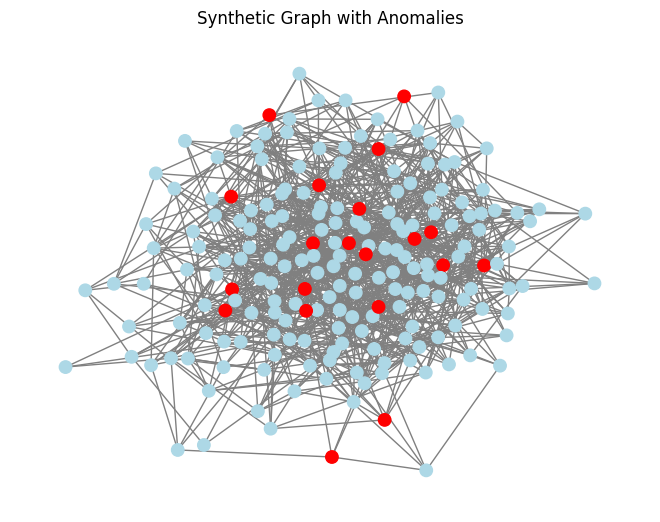

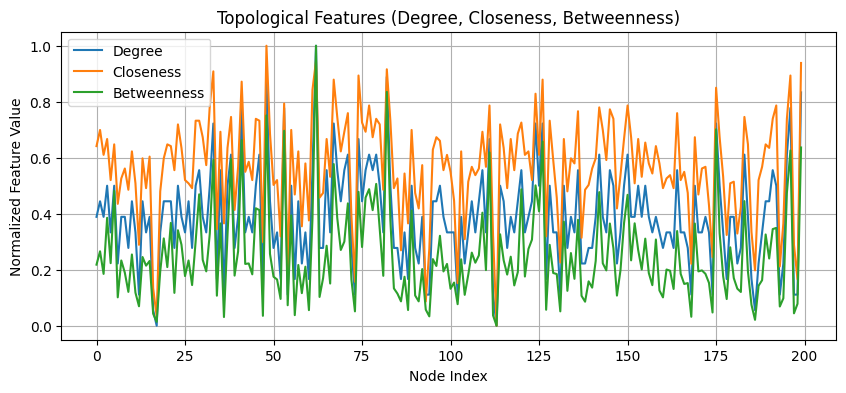

In [ ]:
plot_graph(G, anomaly_indices)
plot_topo_features(topo_feats)


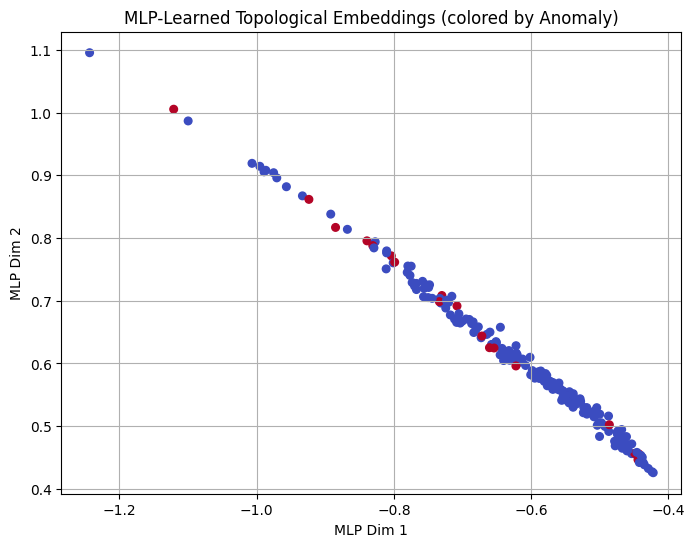

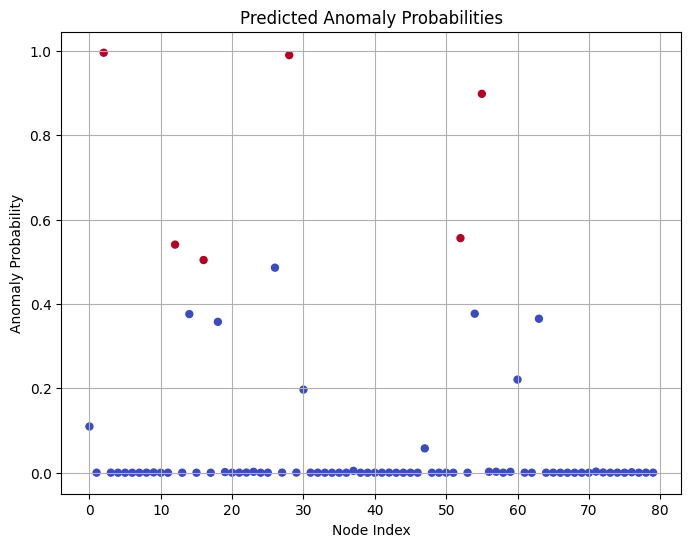

In [ ]:
import matplotlib.pyplot as plt

# Extract MLP outputs (Topo embeddings)
with torch.no_grad():
    mlp_output = model.mlp(topo_feats).numpy()

# Plot the MLP-learned representations (2D projection)
plt.figure(figsize=(8, 6))
plt.scatter(mlp_output[:, 0], mlp_output[:, 1], c=labels, cmap='coolwarm', s=30)
plt.title("MLP-Learned Topological Embeddings (colored by Anomaly)")
plt.xlabel("MLP Dim 1")
plt.ylabel("MLP Dim 2")
plt.grid(True)
plt.show()

# Plot anomaly prediction results
with torch.no_grad():
    preds_binary = (probs > 0.5).float().numpy()
    plt.figure(figsize=(8, 6))
    plt.scatter(range(len(probs)), probs.numpy(), c=preds_binary, cmap='coolwarm', s=25)
    plt.title("Predicted Anomaly Probabilities")
    plt.xlabel("Node Index")
    plt.ylabel("Anomaly Probability")
    plt.grid(True)
    plt.show()


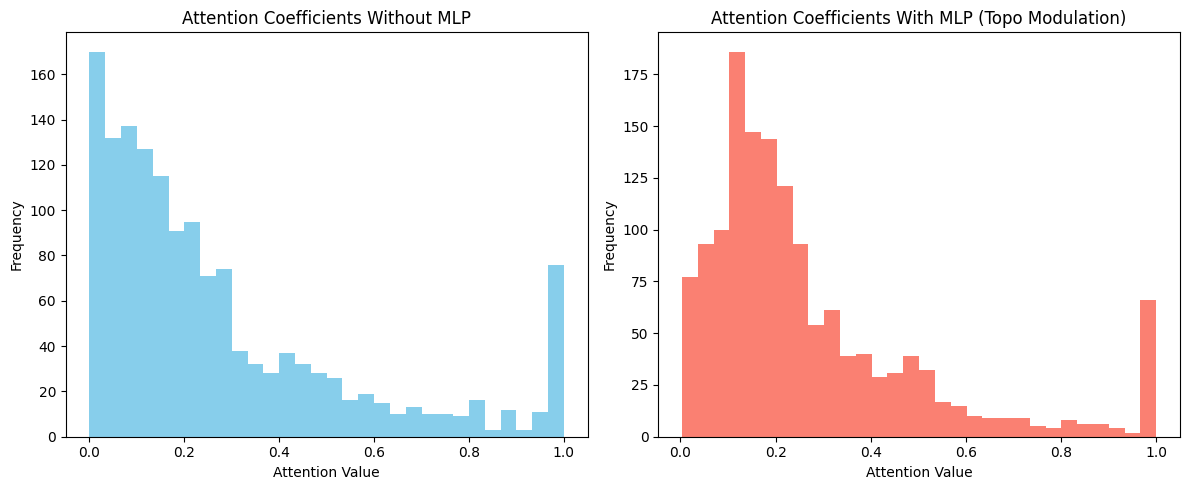

In [ ]:
# Re-import necessary libraries after state reset
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, f1_score
import random

# Recreate synthetic graph
num_nodes = 100
G = nx.erdos_renyi_graph(num_nodes, 0.05)
edges = list(G.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
x = torch.randn((num_nodes, 16))
labels = torch.zeros(num_nodes)
anomaly_indices = random.sample(range(num_nodes), int(0.1 * num_nodes))
labels[anomaly_indices] = 1
x[anomaly_indices] = torch.randn_like(x[anomaly_indices]) * 3

# Compute filtration-based topo features
degree = np.array([val for _, val in G.degree()])
closeness = np.array(list(nx.closeness_centrality(G).values()))
betweenness = np.array(list(nx.betweenness_centrality(G).values()))
filtrations = np.vstack([degree, closeness, betweenness]).T
topo_feats = torch.tensor(MinMaxScaler().fit_transform(filtrations), dtype=torch.float32)

# Masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[:int(0.6 * num_nodes)] = True
test_mask = ~train_mask
data = Data(x=x, edge_index=edge_index, y=labels, train_mask=train_mask, test_mask=test_mask)

# Define GAT with MLP
class TopoGAT(nn.Module):
    def __init__(self, in_dim, topo_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(topo_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.gat1 = GATConv(in_dim + 8, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index, topo_feat):
        z = self.mlp(topo_feat)
        x_aug = torch.cat([x, z], dim=1)
        return self.gat1(x_aug, edge_index, return_attention_weights=True)

# Define plain GAT without MLP
class PlainGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index):
        return self.gat1(x, edge_index, return_attention_weights=True)

# Instantiate and get attention weights
model = TopoGAT(16, 3, 8, 2)
plain_model = PlainGAT(16, 8, 2)
model.eval(), plain_model.eval()

with torch.no_grad():
    _, attn_with_mlp = model(x, edge_index, topo_feats)
    _, attn_plain = plain_model(x, edge_index)

# Flatten attention weights safely
attn_plain_weights = attn_plain[1].reshape(-1).cpu().numpy()
attn_with_mlp_weights = attn_with_mlp[1].reshape(-1).cpu().numpy()

# Plotting attention weights
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(attn_plain_weights, bins=30, color='skyblue')
plt.title("Attention Coefficients Without MLP")
plt.xlabel("Attention Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(attn_with_mlp_weights, bins=30, color='salmon')
plt.title("Attention Coefficients With MLP (Topo Modulation)")
plt.xlabel("Attention Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
